In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import cv2

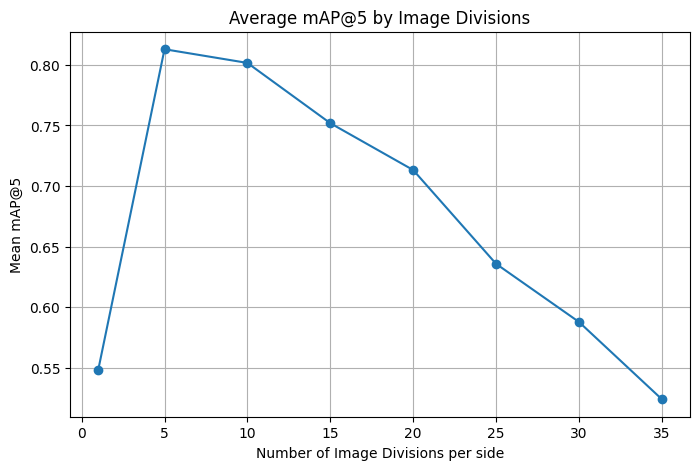

,hier_level,mAP@5
0,1,0.548356
1,5,0.812801
2,10,0.801505
3,15,0.751829
4,20,0.713218
5,25,0.635903
6,30,0.587986
7,35,0.524282


In [2]:
# Load CSV
df = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_big.csv")

# Extract the number after "hier" in the descriptor column
df['hier_level'] = df['descriptor'].apply(lambda x: int(re.search(r"hier(\d+)", x).group(1)) if re.search(r"hier(\d+)", x) else None)

# Group by hier_level and compute mean of "mAP@5"
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(mean_scores['hier_level'], mean_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Mean mAP@5")
plt.title("Average mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

mean_scores

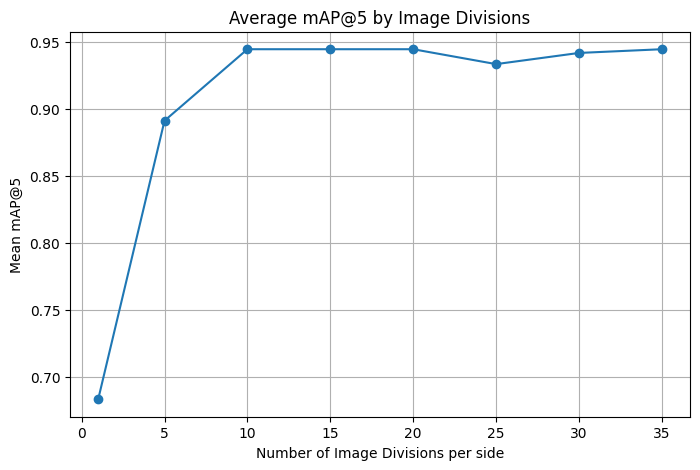

,hier_level,mAP@5
0,1,0.683333
1,5,0.891111
2,10,0.944444
3,15,0.944444
4,20,0.944444
5,25,0.933333
6,30,0.941667
7,35,0.944444


In [ ]:
# Group by hier_level and compute mean of "mAP@5"
max_scores = df.groupby('hier_level')['mAP@5'].max().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(max_scores['hier_level'], max_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Max mAP@5")
plt.title("Max mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

max_scores

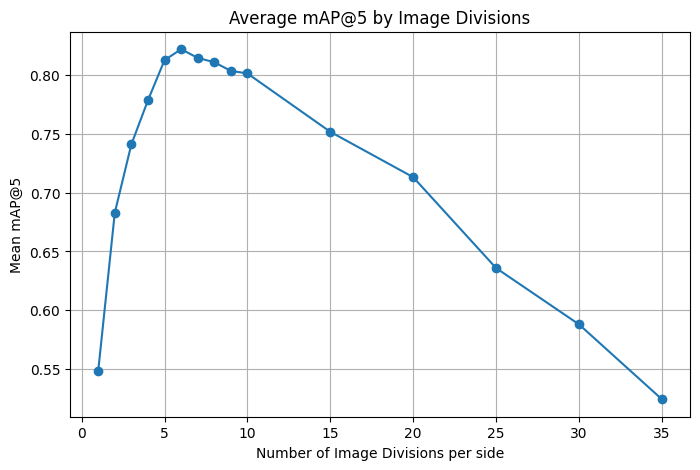

    hier_level     mAP@5
0            1  0.548356
1            2  0.682940
2            3  0.741134
3            4  0.778634
4            5  0.812801
5            6  0.822106
6            7  0.814769
7            8  0.811019
8            9  0.803704
9           10  0.801505
10          15  0.751829
11          20  0.713218
12          25  0.635903
13          30  0.587986
14          35  0.524282


In [4]:
# --- Load and merge CSV files vertically ---
df1 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_big.csv")
df2 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_small.csv")

# Merge vertically (stack rows)
df = pd.concat([df1, df2], ignore_index=True)

# --- Extract the number after "hier" in the descriptor column ---
df['hier_level'] = df['descriptor'].apply(
    lambda x: int(re.search(r"hier(\d+)", x).group(1)) if re.search(r"hier(\d+)", x) else None
)

# --- Group by hier_level and compute mean of "mAP@5" ---
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(mean_scores['hier_level'], mean_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Mean mAP@5")
plt.title("Average mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

# Display the first few results
print(mean_scores)

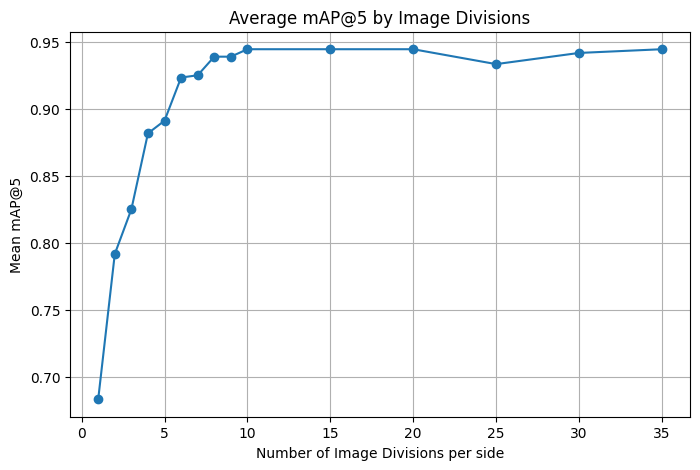

    hier_level     mAP@5
0            1  0.683333
1            2  0.791667
2            3  0.825000
3            4  0.881667
4            5  0.891111
5            6  0.923333
6            7  0.925000
7            8  0.938889
8            9  0.938889
9           10  0.944444
10          15  0.944444
11          20  0.944444
12          25  0.933333
13          30  0.941667
14          35  0.944444


In [ ]:
# --- Group by hier_level and compute max of "mAP@5" ---
max_scores = df.groupby('hier_level')['mAP@5'].max().reset_index()

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(max_scores['hier_level'], max_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Max mAP@5")
plt.title("Max mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

# Display the first few results
print(max_scores)

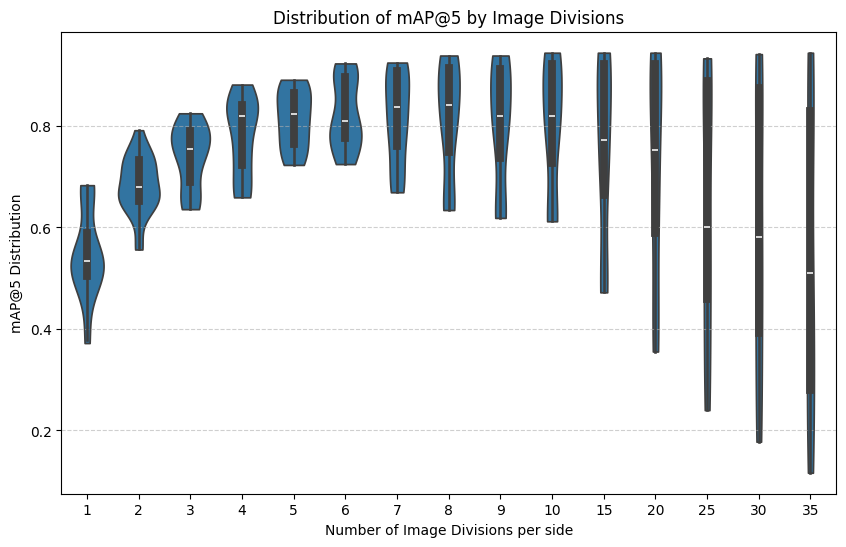

    hier_level     mAP@5
0            1  0.548356
1            2  0.682940
2            3  0.741134
3            4  0.778634
4            5  0.812801
5            6  0.822106
6            7  0.814769
7            8  0.811019
8            9  0.803704
9           10  0.801505
10          15  0.751829
11          20  0.713218
12          25  0.635903
13          30  0.587986
14          35  0.524282


In [6]:
# --- Load and merge CSV files vertically ---
df1 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_big.csv")
df2 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_small.csv")

# Merge vertically (stack rows)
df = pd.concat([df1, df2], ignore_index=True)

# --- Extract the number after "hier" in the descriptor column ---
df['hier_level'] = df['descriptor'].apply(
    lambda x: int(re.search(r"hier(\d+)", x).group(1)) if re.search(r"hier(\d+)", x) else None
)

# --- Drop NaN hier_levels (just in case) ---
df = df.dropna(subset=['hier_level'])

# --- Violin plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='hier_level', y='mAP@5', data=df, inner='box', cut=0)

plt.xlabel("Number of Image Divisions per side")
plt.ylabel("mAP@5 Distribution")
plt.title("Distribution of mAP@5 by Image Divisions")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

# Display mean values for reference
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()
print(mean_scores)

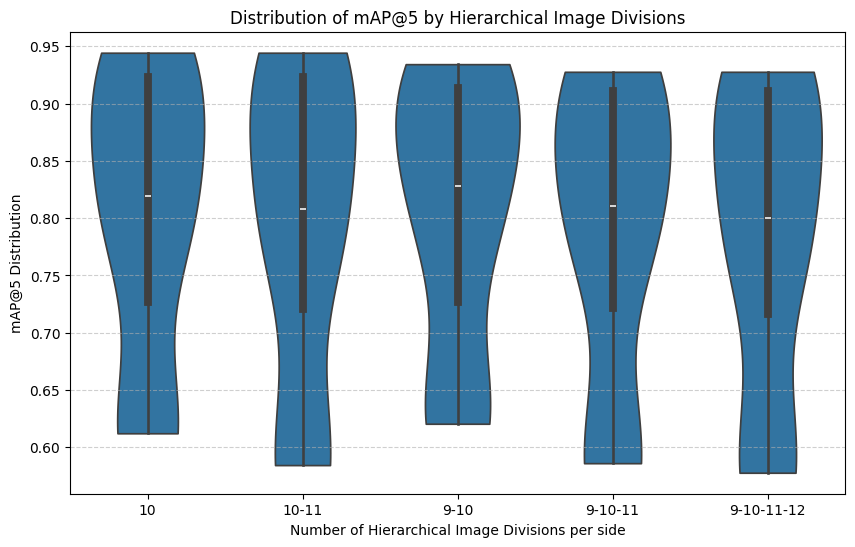

   hier_level     mAP@5
0          10  0.801505
1       10-11  0.792153
2        9-10  0.803889
3     9-10-11  0.787731
4  9-10-11-12  0.783125


In [8]:
# Load CSV
df = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_actually_hierarchical.csv")

# --- Extract the number after "hier" in the descriptor column ---
df['hier_level'] = df['descriptor'].apply(
    lambda x: re.search(r"hier([0-9\-]+)", x).group(1) if re.search(r"hier([0-9\-]+)", x) else None
)

# --- Drop NaN hier_levels (just in case) ---
df = df.dropna(subset=['hier_level'])

# --- Violin plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='hier_level', y='mAP@5', data=df, inner='box', cut=0)

plt.xlabel("Number of Hierarchical Image Divisions per side")
plt.ylabel("mAP@5 Distribution")
plt.title("Distribution of mAP@5 by Hierarchical Image Divisions")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

# Display mean values for reference
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()
print(mean_scores)

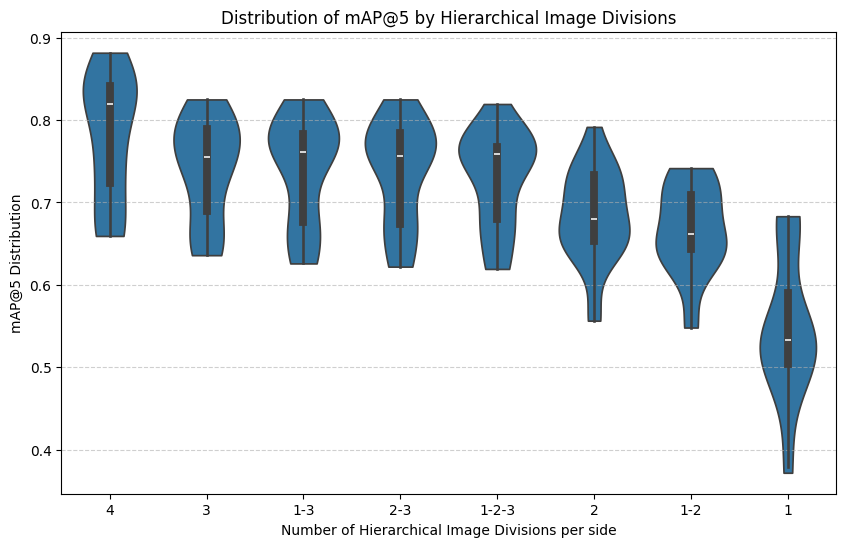

  hier_level     mAP@5
0          1  0.548356
1        1-2  0.667153
2      1-2-3  0.728634
3        1-3  0.739954
4          2  0.682940
5        2-3  0.736273
6          3  0.741134
7          4  0.778634


In [9]:
# Load CSV
df = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical.csv")

# --- Extract the number after "hier" in the descriptor column ---
df['hier_level'] = df['descriptor'].apply(
    lambda x: re.search(r"hier([0-9\-]+)", x).group(1) if re.search(r"hier([0-9\-]+)", x) else None
)

# --- Drop NaN hier_levels (just in case) ---
df = df.dropna(subset=['hier_level'])

# --- Violin plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='hier_level', y='mAP@5', data=df, inner='box', cut=0)

plt.xlabel("Number of Hierarchical Image Divisions per side")
plt.ylabel("mAP@5 Distribution")
plt.title("Distribution of mAP@5 by Hierarchical Image Divisions")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

# Display mean values for reference
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()
print(mean_scores)

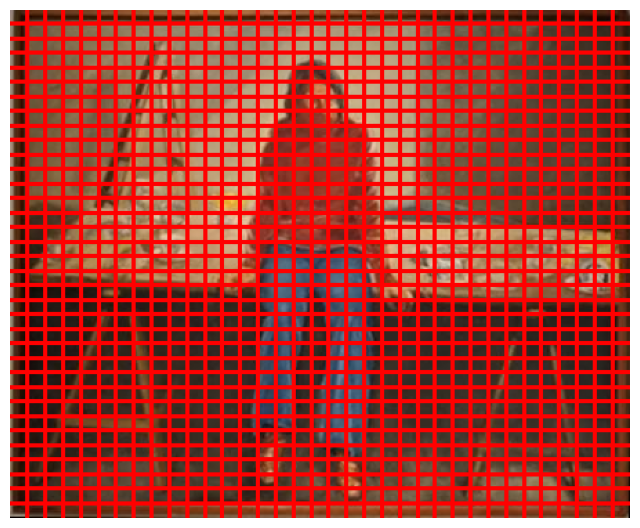

In [16]:
# === CONFIG ===
image_path = "/home/gerardasbert/Desktop/Master/C1/projecte/Team3/data/qsd1_w1/00009.jpg"  # <-- Change this to your image file
num_vertical = 35
num_horizontal = 35

# === READ IMAGE ===
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# Convert BGR (OpenCV) to RGB (Matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

# === DRAW GRID LINES ===
# Create a copy to draw on
grid_img = img_rgb.copy()

# Vertical lines
for i in range(1, num_vertical):
    x = int(i * w / num_vertical)
    cv2.line(grid_img, (x, 0), (x, h), (255, 0, 0), 2)

# Horizontal lines
for j in range(1, num_horizontal):
    y = int(j * h / num_horizontal)
    cv2.line(grid_img, (0, y), (w, y), (255, 0, 0), 2)

# === DISPLAY ===
plt.figure(figsize=(8, 8))
plt.imshow(grid_img)
plt.axis("off")
plt.show()

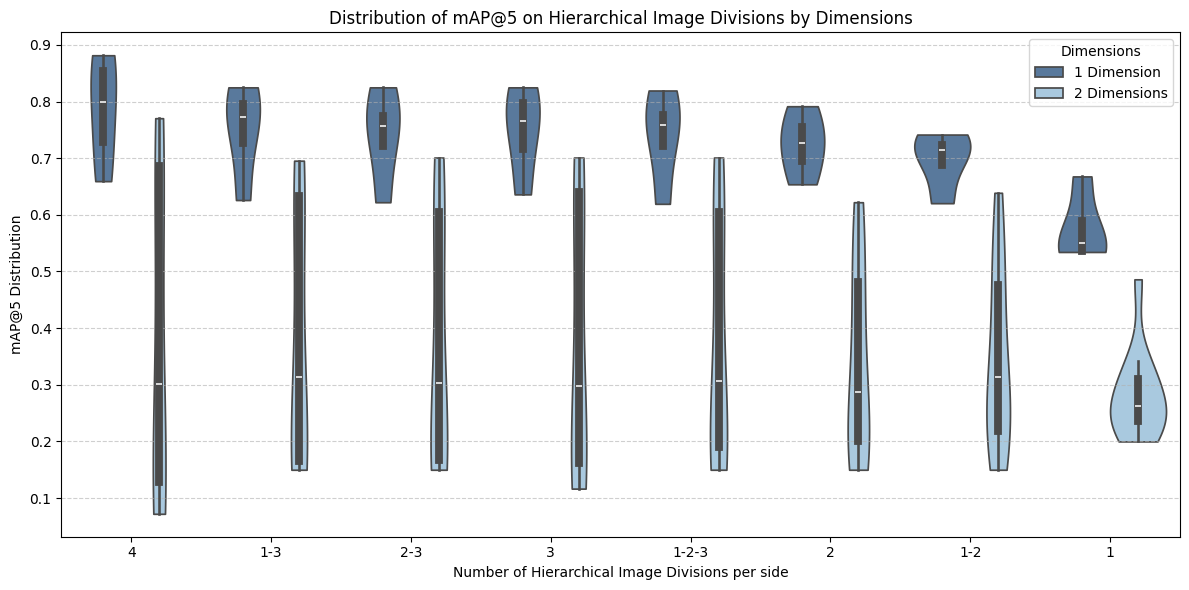

   hier_level        source     mAP@5
0           1   1 Dimension  0.575556
1           1  2 Dimensions  0.281898
2         1-2   1 Dimension  0.697361
3         1-2  2 Dimensions  0.343657
4       1-2-3   1 Dimension  0.739167
5       1-2-3  2 Dimensions  0.369167
6         1-3   1 Dimension  0.749167
7         1-3  2 Dimensions  0.373194
8           2   1 Dimension  0.724444
9           2  2 Dimensions  0.334120
10        2-3   1 Dimension  0.740278
11        2-3  2 Dimensions  0.365556
12          3   1 Dimension  0.748194
13          3  2 Dimensions  0.368472
14          4   1 Dimension  0.784722
15          4  2 Dimensions  0.367130


In [24]:
# === FILE PATHS ===
csv_paths = {
    "1 Dimension": "/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_blocks_1D.csv",
    "2 Dimensions": "/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_blocks_2D.csv",
}

# === LOAD AND COMBINE DATA ===
dfs = []
for label, path in csv_paths.items():
    df = pd.read_csv(path)
    
    # Extract number after "hier" from descriptor column
    df['hier_level'] = df['descriptor'].apply(
        lambda x: re.search(r"hier([0-9\-]+)", x).group(1) if re.search(r"hier([0-9\-]+)", x) else None
    )
    df = df.dropna(subset=['hier_level'])
    
    df['source'] = label  # Label which CSV it came from
    dfs.append(df)

# Combine all
df_all = pd.concat(dfs, ignore_index=True)

# === VIOLIN PLOT ===
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='hier_level',
    y='mAP@5',
    hue='source',
    data=df_all,
    inner='box',
    cut=0,
    palette={"1 Dimension": "#4E79A7", "2 Dimensions": "#A0CBE8"}
)

plt.xlabel("Number of Hierarchical Image Divisions per side")
plt.ylabel("mAP@5 Distribution")
plt.title("Distribution of mAP@5 on Hierarchical Image Divisions by Dimensions")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Dimensions", loc='best')
plt.tight_layout()
plt.show()

# === MEAN VALUES FOR REFERENCE ===
mean_scores = df_all.groupby(['hier_level', 'source'])['mAP@5'].mean().reset_index()
print(mean_scores)

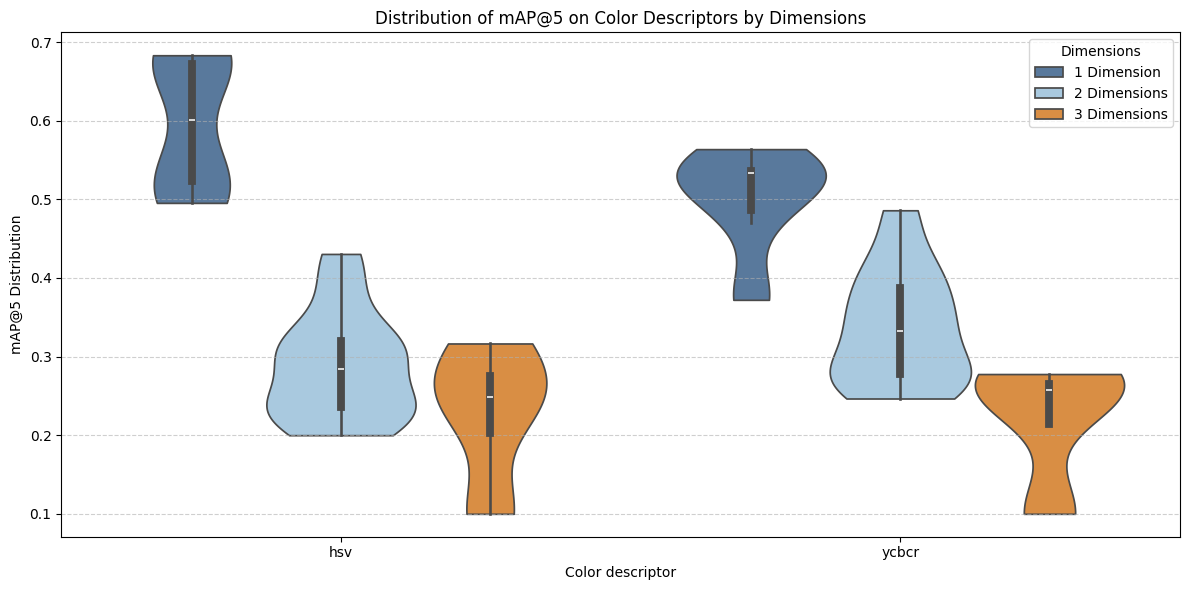

  category        source     mAP@5
0      hsv   1 Dimension  0.596065
1      hsv  2 Dimensions  0.288333
2      hsv  3 Dimensions  0.228750
3    ycbcr   1 Dimension  0.500648
4    ycbcr  2 Dimensions  0.337546
5    ycbcr  3 Dimensions  0.222917


In [25]:
# === FILE PATHS ===
csv_paths = {
    "1 Dimension": "/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_basic_1D.csv",
    "2 Dimensions": "/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_basic_2D.csv",
    "3 Dimensions": "/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_basic_3D.csv",
}

# === LOAD AND COMBINE DATA ===
dfs = []
for label, path in csv_paths.items():
    df = pd.read_csv(path)
    
    # Extract the first word before the first underscore
    df['category'] = df['descriptor'].apply(
        lambda x: re.match(r"([^_]+)", x).group(1) if re.match(r"([^_]+)", x) else None
    )
    df = df.dropna(subset=['category'])
    
    df['source'] = label  # Label which CSV it came from
    dfs.append(df)

# Combine all
df_all = pd.concat(dfs, ignore_index=True)

# === VIOLIN PLOT ===
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='category',
    y='mAP@5',
    hue='source',
    data=df_all,
    inner='box',
    cut=0,
    palette={"1 Dimension": "#4E79A7", "2 Dimensions": "#A0CBE8", "3 Dimensions": "#F28E2B"}
)

plt.xlabel("Color descriptor")
plt.ylabel("mAP@5 Distribution")
plt.title("Distribution of mAP@5 on Color Descriptors by Dimensions")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Dimensions", loc='best')
plt.tight_layout()
plt.show()

# === MEAN VALUES FOR REFERENCE ===
mean_scores = df_all.groupby(['category', 'source'])['mAP@5'].mean().reset_index()
print(mean_scores)